### Code
Before running this notebook, be sure to install `jax_moseq` and its associated dependencies. This notebook also requires `tqdm` and `matplotlib`. Also note that while a GPU is not required, it certainly doesn't hurt.

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import numpy as np
import seaborn as sns

import tensorflow_probability.substrates.jax.distributions as tfd
from dynamax.utils.distributions import NormalInverseWishart
from dynamax.hidden_markov_model.models.gaussian_hmm import GaussianHMM
from dynamax.hidden_markov_model.models.arhmm import LinearAutoregressiveHMM
from dynamax.utils.utils import random_rotation
from dynamax.utils.plotting import gradient_cmap

from jax_moseq.models import warhmm

from tqdm.auto import trange
import matplotlib.pyplot as plt


from jax_moseq.models.warhmm.gibbs import M_step

#### Helper Methods

In [2]:
from jax_moseq.utils.autoregression import timescale_weights_covs, ar_log_likelihood
from jax_moseq.utils.distributions import sample_hmm_stateseq
def print_dict(d, depth=0, ind='  '):
    if type(d) != dict:
        try:
            item = d.shape
        except AttributeError:
            item = d
        print(f'{ind * depth}{item}')
        return

    for k, v in d.items():
        print(f'{ind * depth}{k}')
        print_dict(v, depth + 1, ind)

In [3]:
def plot_ll(key, ll_history):
    plt.title(f'Log Likelihood of {key}')
    plt.xlabel('Iteration')
    plt.ylabel('Log Likelihood')
    plt.plot(ll_history)
    plt.show()

#### Loading the Data
The data is stored in a dictionary with two entries:
- `'x'` - a jax array of shape `(num_sessions, num_timesteps, obs_dim)` containing the continuous observations to which the model will be fit. In this case, these data are 10 dimensional PCA projections of mouse depth images (see Wiltschko et al. 2015) sampled at 30 fps.
- `'mask'` - a jax array of shape `(num_sessions, num_timesteps)` indicating which data points are valid (which is useful in the event that data for each session differs in length).

In [4]:
def random_emissions_and_mask(seed, num_sessions, num_timesteps, num_states, emission_dim, num_mask):
    """Generate random HMM arguments, log-likelihoods, and masking.

    Arguments
        num_timesteps (int): number of timesteps in sequence, T
        num_states (int): number of hmm states, K
        scale (float): covariance scale
        num_mask (int): number of timesteps to mask

    Returns
        hmm (GaussianHMM)
        mask: shape [T]
    """
    seed_init, seed_sample, seed_mask = jr.split(seed, 3)

    hmm = GaussianHMM(num_states, emission_dim, transition_matrix_stickiness=100)
    params, param_props = hmm.initialize(seed_init)

    states, emissions = jax.vmap(hmm.sample, in_axes=(None, 0, None))\
                                (params, jr.split(seed_sample, num_sessions), num_timesteps)

    # Randomly mask sum observations
    mask = jnp.ones((num_sessions, num_timesteps), dtype=int)
    if num_mask > 0:
        i_flip = jax.vmap(jr.randint, in_axes=(0,None, None, None))\
                         (jr.split(seed_mask, num_sessions), (num_mask,), 0, num_timesteps)
        mask = mask.at[i_flip].set(0)

    return (params, param_props), states, emissions, mask


In [5]:
def emissions_and_mask_arhmm(seed, num_sessions, num_timesteps, num_states, tau_list, emission_dim, num_mask):
    """Generate random HMM arguments, log-likelihoods, and masking.

    Arguments
        num_timesteps (int): number of timesteps in sequence, T
        num_states (int): number of hmm states, K
        scale (float): covariance scale
        num_mask (int): number of timesteps to mask

    Returns
        hmm (GaussianHMM)
        mask: shape [T]
    """
    transition_probs = (jnp.arange(num_states)**10).astype(float)
    transition_probs /= transition_probs.sum()
    transition_matrix = jnp.zeros((num_states, num_states))
    for k, p in enumerate(transition_probs[::-1]):
        transition_matrix += jnp.roll(p * jnp.eye(num_states), k, axis=1)

    # Make observation distributions
    emission_dim = 2
    num_lags = 1

    keys = jr.split(jr.PRNGKey(0), num_states)
    angles = jnp.linspace(0, 2 * jnp.pi, num_states, endpoint=False)
    theta = jnp.pi / 25 # rotational frequency
    weights = jnp.array([0.8 * random_rotation(key, emission_dim, theta=theta) for key in keys])
    biases = jnp.column_stack([jnp.cos(angles), jnp.sin(angles), jnp.zeros((num_states, emission_dim - 2))])
    covariances = jnp.tile(0.001 * jnp.eye(emission_dim), (num_states, 1, 1))

    # Make an Autoregressive (AR) HMM
    true_arhmm = LinearAutoregressiveHMM(num_states, emission_dim, num_lags=num_lags)
    true_params, true_param_props = true_arhmm.initialize(initial_probs=jnp.ones(num_states) / num_states,
                                           transition_matrix=transition_matrix,
                                           emission_weights=weights,
                                           emission_biases=biases,
                                           emission_covariances=covariances)

    true_states, emissions = jax.vmap(true_arhmm.sample, in_axes=(None, 0, None))\
        (true_params, jr.split(seed, num_sessions), num_timesteps)

    # Randomly mask sum observations
    mask = jnp.ones((num_sessions, num_timesteps), dtype=int)
    if num_mask > 0:
        i_flip = jax.vmap(jr.randint, in_axes=(0,None, None, None))\
                         (jr.split(seed, num_sessions), (num_mask,), 0, num_timesteps)
        mask = mask.at[i_flip].set(0)

    return (true_params, true_param_props), true_states, emissions, mask

In [6]:
# =======================
# Loading data from file
# =======================

# x_path = 'example_data.npy'
# x = np.load(x_path)

# data = {'x': jax.device_put(x),
#         'mask': jnp.ones((x.shape[:2]))}
# del x

# print_dict(data)

# =========================
# Randomly generating data
# =========================

# TODO Generate data from AR-HMM, as opposed to HMM
# So that the log likelihoods below look okay

num_states = 5
num_sessions = 10
num_timesteps = 20000
#num_mask = int(0.20 * num_timesteps)
num_mask = 0
obs_dim = 2
seed = jr.PRNGKey(3420)
tau_list = jnp.array([1])

hmm_param_and_props, states, emissions, mask \
    = emissions_and_mask_arhmm(seed, num_sessions, num_timesteps, num_states, tau_list, obs_dim, num_mask)

data = {'x': jax.device_put(emissions),
        'mask': jax.device_put(mask)}

print_dict(data)

x
  (10, 20000, 2)
mask
  (10, 20000)


Text(0, 0.5, '$x_2$')

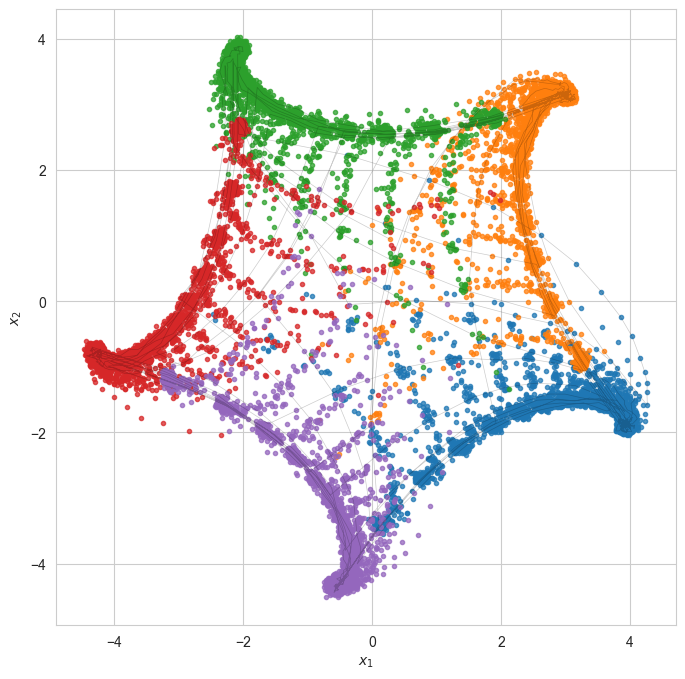

In [7]:
# Plot the sampled data
fig = plt.figure(figsize=(8, 8))
for k in range(num_states):
    plt.plot(*emissions[0][states[0]==k].T, 'o',
         alpha=0.75, markersize=3)

plt.plot(*emissions[0,:1000].T, '-k', lw=0.5, alpha=0.2)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

#### Setting the Hyperparameters

In [8]:
latent_dim = obs_dim = data['x'].shape[-1]
num_states = 5          # max number of states
nlags = 1                 # number of lags for AR dynamics
possible_taus = jnp.array([1])

trans_hypparams = {
    'gamma': 1e3,
    'alpha': 5.7,
    'kappa': 1e6,
    'num_states':num_states,
    'num_taus':len(possible_taus),
    'tau_stay':0.9
}

ar_hypparams = {
    'S_0_scale': .01,
    'K_0_scale': 10,
    'num_states':num_states,
    'tau_list':possible_taus,
    'nlags':  nlags,
    'latent_dim': latent_dim
}

#### Fitting the Model

In [45]:
model = warhmm.init_model(data,
                          taus=possible_taus,
                         ar_hypparams=ar_hypparams,
                         trans_hypparams=trans_hypparams,
                         verbose=True)

model['states']['z'] = states.copy()
model['states']['t'] = jnp.zeros_like(states)
print_dict(model)

T-WARHMM: Initializing hyperparameters
T-WARHMM: Initializing parameters
T-WARHMM: Initializing states
seed
  (2,)
hypparams
  trans_hypparams
    gamma
      1000.0
    alpha
      5.7
    kappa
      1000000.0
    num_states
      5
    num_taus
      1
    tau_stay
      0.9
  ar_hypparams
    S_0_scale
      0.01
    K_0_scale
      10
    num_states
      5
    tau_list
      (1,)
    nlags
      1
    latent_dim
      2
    S_0
      (2, 2)
    K_0
      (3, 3)
    M_0
      (2, 3)
    num_taus
      1
    tau_stay
      0.9
    nu_0
      4
params
  betas_z
    (5,)
  pi_z
    (5, 5)
  betas_t
    (1,)
  pi_t
    (1, 1)
  Ab
    (5, 2, 3)
  Q
    (5, 2, 2)
  possible_taus
    (1,)
states
  z
    (10, 20000)
  t
    (10, 20000)


In [46]:
true_Ab = jnp.concatenate((hmm_param_and_props[0].emissions.weights, hmm_param_and_props[0].emissions.biases[:,:,None]),axis=-1)
true_Q = hmm_param_and_props[0].emissions.covs

In [47]:
model['params']['Ab'] = true_Ab.copy()
model['params']['Q'] = true_Q.copy()

In [48]:
num_iters = 10    # number of training iterations

ll_keys = ['z', 'x']
ll_history = {key: [] for key in ll_keys}

for i in trange(num_iters):
    # Perform Gibbs resampling
    model = warhmm.resample_model(data, **model)

    # Compute the likelihood of the data and
    # resampled states given the resampled params
    ll = warhmm.model_likelihood(data, **model)
    for key in ll_keys:
        ll_history[key].append(ll[key].item())

  0%|          | 0/10 [00:00<?, ?it/s]

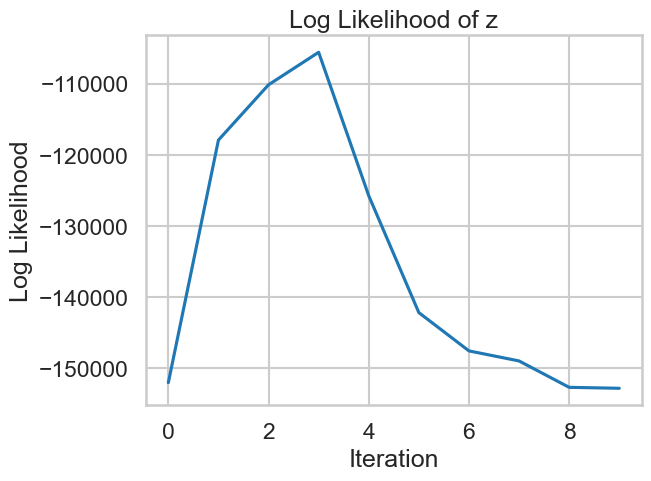

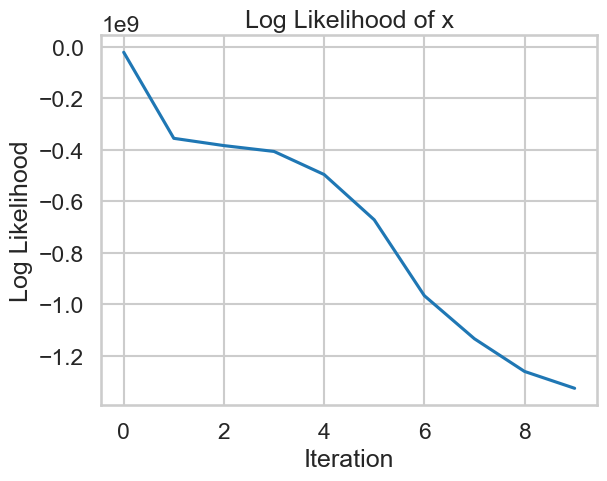

In [49]:
for k, v in ll_history.items():
    plot_ll(k, v)

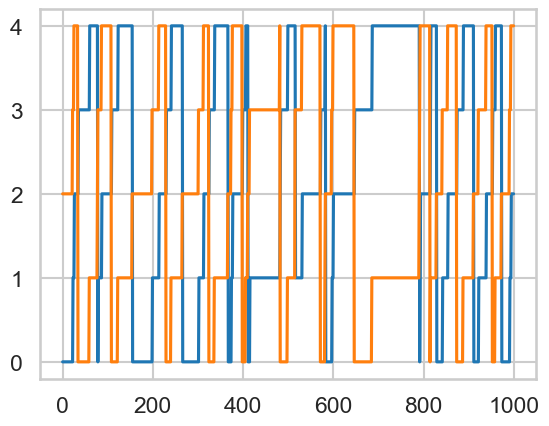

In [50]:
plt.plot(states[-1][:1000])
plt.plot(model['states']['z'][-1][:1000])

In [37]:
model['states']['t'].sum()

Array(0, dtype=int32)

In [51]:
sns.set_style("white")
sns.set_context("talk")

color_names = [
    "windows blue",
    "red",
    "amber",
    "faded green",
    "dusty purple",
    "orange",
    "brown",
    "pink"
]

colors = sns.xkcd_palette(color_names)
cmap = gradient_cmap(colors)

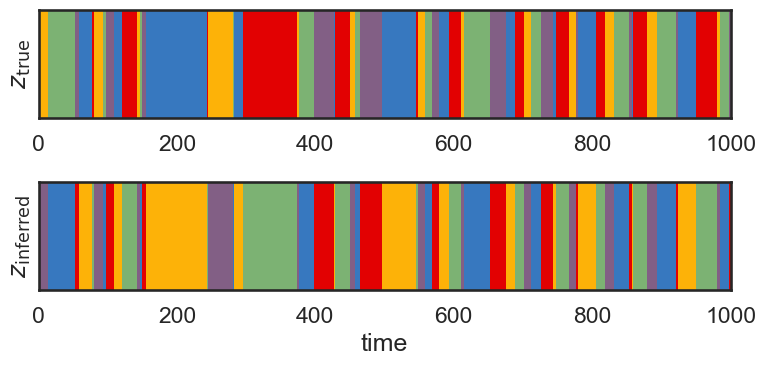

In [52]:
plot_slice = (0, 1000)
plt.figure(figsize=(8, 4))
plt.subplot(211)
plt.imshow(states[None, 0, ar_hypparams['nlags']:], aspect="auto", interpolation="none", cmap=cmap, vmin=0, vmax=len(colors)-1)
plt.xlim(plot_slice)
plt.ylabel("$z_{\\mathrm{true}}$")
plt.yticks([])

plt.subplot(212)
plt.imshow(model['states']['z'][None,0,:], aspect="auto", interpolation="none", cmap=cmap, vmin=0, vmax=len(colors)-1)
plt.xlim(plot_slice)
plt.ylabel("$z_{\\mathrm{inferred}}$")
plt.yticks([])
plt.xlabel("time")

plt.tight_layout()

Text(0, 0.5, '$x_2$')

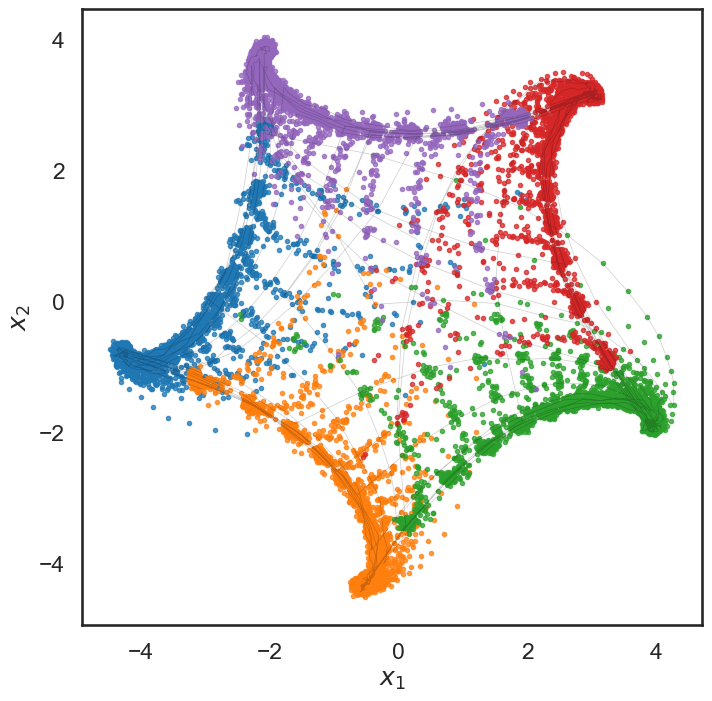

In [53]:
# Plot the sampled data
fig = plt.figure(figsize=(8, 8))
for k in range(num_states):
    plt.plot(*emissions[0,1:][model['states']['z'][0]==k].T, 'o',
         alpha=0.75, markersize=3)

plt.plot(*emissions[0,:1000].T, '-k', lw=0.5, alpha=0.2)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")

In [16]:

model['states']['z'][None,0,:]

Array([[0, 0, 0, ..., 0, 0, 0]], dtype=int32)

In [17]:
states[None, 0, ar_hypparams['nlags']:]


Array([[2, 2, 2, ..., 3, 3, 3]], dtype=int32)

In [69]:
from functools import partial
from jax_moseq.utils.autoregression import (
    get_lags,
    get_nlags,
    ar_log_likelihood,
    timescale_weights_covs
)
from jax_moseq.utils.distributions import (
    sample_mniw,
    sample_hmm_stateseq
)
#TODO: how does Ab here relate to Ab in our model? should they be the same?
weights = hmm_param_and_props[0].emissions.weights
biases = hmm_param_and_props[0].emissions.biases
Ab_eye = jnp.concatenate((weights, biases[:,:,None]), axis=2)
Ab = Ab_eye - jnp.tile((jnp.concatenate((jnp.eye(2), jnp.zeros((2,1))), axis=1)),(Ab_eye.shape[0],1,1))
Q = hmm_param_and_props[0].emissions.covs

pi_z = hmm_param_and_props[0].transitions.transition_matrix
pi_t = jnp.array([[1]])

x = data['x']
warhmm.resample_discrete_stateseqs(seed, x, mask, Ab_eye, Q, pi_z, pi_t, possible_taus)

(Array([[2, 2, 2, ..., 3, 3, 3],
        [0, 0, 0, ..., 4, 0, 0],
        [2, 2, 2, ..., 2, 2, 2],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [1, 1, 1, ..., 4, 4, 4],
        [0, 0, 0, ..., 1, 1, 1]], dtype=int32),
 Array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=int32))

In [66]:
nlags = 1
num_samples = mask.shape[0]
num_states = Ab.shape[0]
num_taus = len(possible_taus)

# get timescaled weights and covs
timescaled_weights, timescaled_covs = timescale_weights_covs(Ab, Q, possible_taus)
timescaled_weights_adj = timescaled_weights #- jnp.tile((jnp.concatenate((jnp.eye(2), jnp.zeros((2,1))), axis=1)),(timescaled_weights.shape[0],1,1))
#TODO: check line above, may want to subtract from Ab before timescaling and then leave timescaled weights/covs alone?

log_likelihoods = jax.lax.map(partial(ar_log_likelihood, x), (timescaled_weights_adj, timescaled_covs))
_, samples = jax.vmap(sample_hmm_stateseq, in_axes=(0,None,0,0))(
    jr.split(seed, num_samples),
    jnp.kron(pi_z, pi_t),
    jnp.moveaxis(log_likelihoods,0,-1),
    mask.astype(float)[:,nlags:])

# split into z and t
z = samples // num_taus
t = jnp.mod(samples, num_taus)

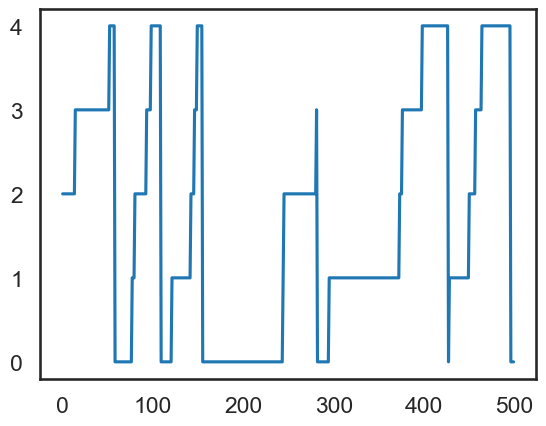

In [67]:
plt.plot(samples[0,:500])

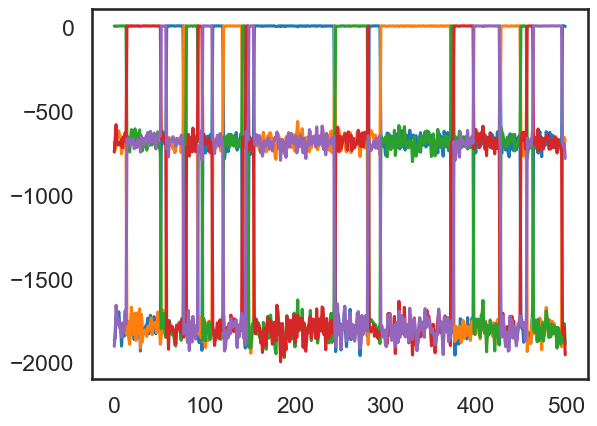

In [21]:
plt.plot(log_likelihoods[:,0,:500].T)

In [22]:
jnp.moveaxis(log_likelihoods,0,-1).shape


(10, 19999, 5)

In [23]:
jnp.kron(pi_z, pi_t)

Array([[9.4581336e-01, 5.3262077e-02, 9.2364586e-04, 9.0199791e-07,
        0.0000000e+00],
       [0.0000000e+00, 9.4581336e-01, 5.3262077e-02, 9.2364586e-04,
        9.0199791e-07],
       [9.0199791e-07, 0.0000000e+00, 9.4581336e-01, 5.3262077e-02,
        9.2364586e-04],
       [9.2364586e-04, 9.0199791e-07, 0.0000000e+00, 9.4581336e-01,
        5.3262077e-02],
       [5.3262077e-02, 9.2364586e-04, 9.0199791e-07, 0.0000000e+00,
        9.4581336e-01]], dtype=float32)

In [24]:
pi_z

Array([[9.4581336e-01, 5.3262077e-02, 9.2364586e-04, 9.0199791e-07,
        0.0000000e+00],
       [0.0000000e+00, 9.4581336e-01, 5.3262077e-02, 9.2364586e-04,
        9.0199791e-07],
       [9.0199791e-07, 0.0000000e+00, 9.4581336e-01, 5.3262077e-02,
        9.2364586e-04],
       [9.2364586e-04, 9.0199791e-07, 0.0000000e+00, 9.4581336e-01,
        5.3262077e-02],
       [5.3262077e-02, 9.2364586e-04, 9.0199791e-07, 0.0000000e+00,
        9.4581336e-01]], dtype=float32)

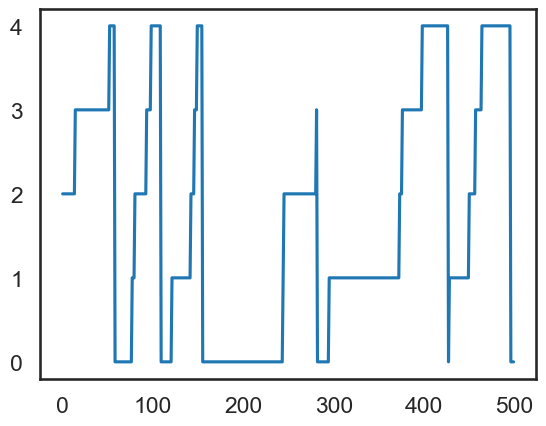

In [25]:
seed = jr.PRNGKey(2)
plt.plot(sample_hmm_stateseq(seed, jnp.kron(pi_z, pi_t),
    jnp.moveaxis(log_likelihoods,0,-1)[0],
    mask.astype(float)[0,nlags:])[1][:500])

In [26]:
from dynamax.hidden_markov_model.inference import hmm_posterior_sample
from jax_moseq.utils import convert_data_precision

transition_matrix_test = jnp.kron(pi_z, pi_t)
log_likelihoods_test = jnp.moveaxis(log_likelihoods,0,-1)[0]
mask_test = mask.astype(float)[0,nlags:]

In [27]:
num_states_test = transition_matrix_test.shape[0]
initial_distribution_test = jnp.ones(num_states_test) / num_states_test
# transition_matrix_test = jnp.eye(5)

masked_log_likelihoods = log_likelihoods_test * mask_test[:, None]
L, z = hmm_posterior_sample(
    seed, initial_distribution_test, transition_matrix_test, masked_log_likelihoods
)
# z = convert_data_precision(z)

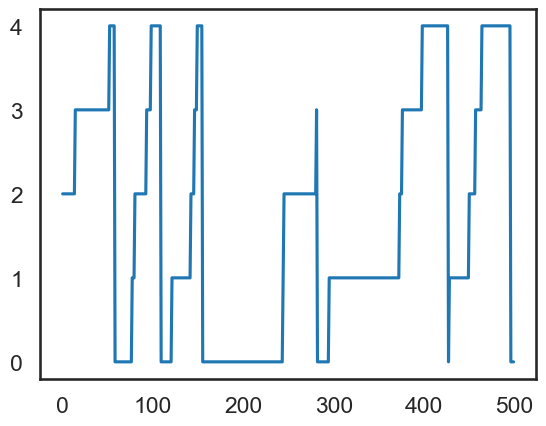

In [28]:
plt.plot(z[:500])

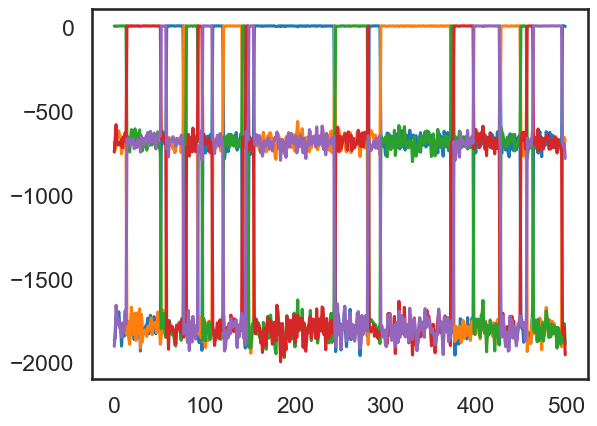

In [29]:
plt.plot(log_likelihoods_test[:500,:])

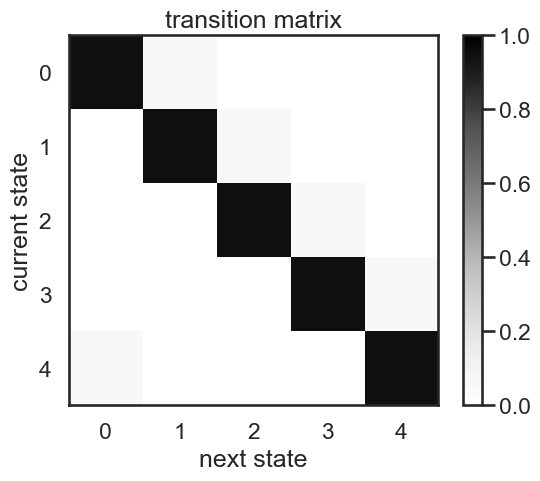

In [30]:
plt.imshow(transition_matrix_test, vmin=0, vmax=1, cmap="Greys")
plt.xlabel("next state")
plt.ylabel("current state")
plt.title("transition matrix")
plt.colorbar()

In [31]:
transition_matrix_test


Array([[9.4581336e-01, 5.3262077e-02, 9.2364586e-04, 9.0199791e-07,
        0.0000000e+00],
       [0.0000000e+00, 9.4581336e-01, 5.3262077e-02, 9.2364586e-04,
        9.0199791e-07],
       [9.0199791e-07, 0.0000000e+00, 9.4581336e-01, 5.3262077e-02,
        9.2364586e-04],
       [9.2364586e-04, 9.0199791e-07, 0.0000000e+00, 9.4581336e-01,
        5.3262077e-02],
       [5.3262077e-02, 9.2364586e-04, 9.0199791e-07, 0.0000000e+00,
        9.4581336e-01]], dtype=float32)

In [32]:
num_samples


10

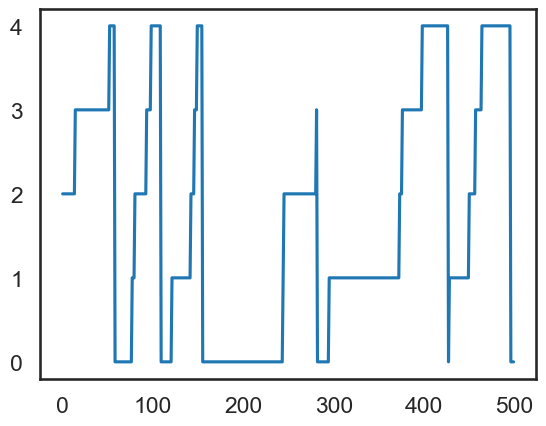

In [33]:
nlags = get_nlags(Ab)
num_samples = mask.shape[0]

log_likelihoods = jax.lax.map(partial(ar_log_likelihood, x), (Ab, Q))
_, z = jax.vmap(sample_hmm_stateseq, in_axes=(0,None,0,0))(
    jr.split(seed, num_samples),
    pi_z,
    jnp.moveaxis(log_likelihoods,0,-1),
    mask.astype(float)[:,nlags:])
plt.plot(z[0,:500])

In [34]:
pi_z == transition_matrix_test

Array([[ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True]], dtype=bool)

In [35]:
transition_matrix_test

Array([[9.4581336e-01, 5.3262077e-02, 9.2364586e-04, 9.0199791e-07,
        0.0000000e+00],
       [0.0000000e+00, 9.4581336e-01, 5.3262077e-02, 9.2364586e-04,
        9.0199791e-07],
       [9.0199791e-07, 0.0000000e+00, 9.4581336e-01, 5.3262077e-02,
        9.2364586e-04],
       [9.2364586e-04, 9.0199791e-07, 0.0000000e+00, 9.4581336e-01,
        5.3262077e-02],
       [5.3262077e-02, 9.2364586e-04, 9.0199791e-07, 0.0000000e+00,
        9.4581336e-01]], dtype=float32)

In [36]:
(timescaled_weights - Ab)

Array([[[1.        , 0.        , 0.        ],
        [0.        , 1.        , 0.        ]],

       [[1.        , 0.        , 0.        ],
        [0.        , 1.        , 0.        ]],

       [[1.        , 0.        , 0.        ],
        [0.        , 1.        , 0.        ]],

       [[1.        , 0.        , 0.        ],
        [0.        , 1.        , 0.        ]],

       [[1.        , 0.        , 0.        ],
        [0.        , 0.99999994, 0.        ]]], dtype=float32)